# ODE symmetry detection examples

The purpose of this notebook is to explore the algebra of reconstructed symmetries for a series of ODE examples.

Workflow:
1. Trajectory generation, from the standard examples.
2. "BASIS_TYPE", "PARAM_RANGE" and "PARAM_LIST" can be changed and re-run to 
explore different basis.
3. SV_CHOICE allows the user to select a set of coefficents from the null space.

## 1. Trajectory generation

Select the ODE example you would like to test. Uses the package-wide defaults for the chosen ODE (via `resolve_ode_args`) —
not tunable here by design; only `ODE` above affects this.

ODE = 'rational'


          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 1500 points/trajectory     │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-15, atol=1.0e-15 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


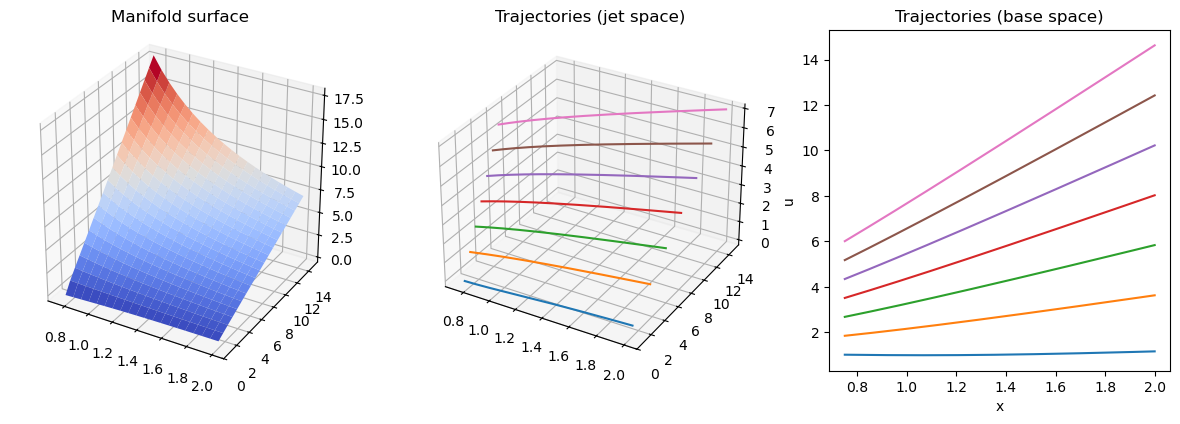

In [48]:
import argparse

import numpy as np
from matplotlib import pyplot as plt

from symmetry_detection import data_matrices as dm
from symmetry_detection import generate_trajectories as gtr
from symmetry_detection import plotting as plot
from symmetry_detection import reporting as rpt
from symmetry_detection import solver

%matplotlib inline

# --- ODE choice ---
# One of gtr.ODES.keys(): "bernoulli", "rational", "riccati", "scaling", "abel"
ODE = "rational"
analytic_derivative = False
num_points = 1500
rtol = 1e-15
atol = 1e-15
print(f"ODE = {ODE!r}")

# Reuse the same resolution function the CLI/example scripts use, so this
# notebook can never disagree with them about what "default" means. Note this
# also resolves rtol/atol (defaults.DEFAULT_RTOL/DEFAULT_ATOL): those matter a
# lot more than num_points for how well the numerical derivative embedding
# (analytic_derivative=False) can agree with the analytic one - see the next
# cell.
ode_args = argparse.Namespace(
    ode=ODE, start=None, end=None, initial_conditions=None, num_points=None, method=None,
    rtol=None, atol=None,
)
ode_args = gtr.resolve_ode_args(ode_args)

X = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=ode_args.initial_conditions,
    num_points=num_points,
    method=ode_args.method,
    rtol=rtol,
    atol=atol,
    analytic_derivative=analytic_derivative
)
X_stacked = gtr.concatenate_trajectories(X)

# Plot the generated trajectories
# Grid of values of the surface manifold over [x_min, x_max] x [u_min, u_max]
x_min, x_max = np.min(X[:, 0, :]), np.max(X[:, 0, :])
u_min, u_max = np.min(X[:, 1, :]), np.max(X[:, 1, :])

res = 20
X_grid = np.linspace(x_min, x_max, res)
U_grid = np.linspace(u_min, u_max, res)
X_grid, U_grid = np.meshgrid(X_grid, U_grid)
P_grid = gtr.ODES[ode_args.ode](X_grid, U_grid)
p_grid_min, p_grid_max = np.min(P_grid), np.max(P_grid)

# Manifold surface, jet-space trajectories, and (x, u) trajectories side by side
manifold_fig = plt.figure(figsize=(12, 4))
ax0 = manifold_fig.add_subplot(131, projection='3d')
ax1 = manifold_fig.add_subplot(132, projection='3d')
ax2 = manifold_fig.add_subplot(133)

ax0.set_aspect('equal')
ax2.set_box_aspect(1)

ax0.plot_surface(X_grid, U_grid, P_grid, cmap='coolwarm')
ax0.set_title("Manifold surface")

for trajectory in X:
    ax1.plot(trajectory[0, :], trajectory[1, :], trajectory[2, :])
    ax2.plot(trajectory[0, :], trajectory[1, :])

ax1.set_title("Trajectories (jet space)")
ax2.set_title("Trajectories (base space)")
ax2.set_xlabel("x")
ax2.set_ylabel("u")

manifold_fig.tight_layout()

### Analytic vs. numerical derivative comparison

Sanity check, independent of the `analytic_derivative` flag chosen above: generate the jet-space
embedding once with the analytic derivative (blue) and once with the numerical (Savitzky-Golay)
derivative (red), and compare two orthogonal projections of the 3D trajectories: `u_x` vs `u`,
and `u_x` vs `x`.

          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 50 points/trajectory       │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 50 points/trajectory       │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative
max |u_x_numeric - u_x_analytic| = 1.555e-03


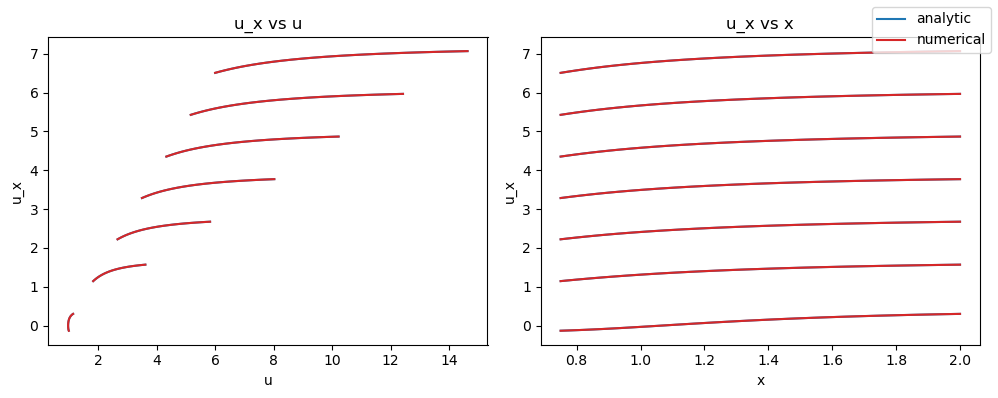

In [26]:
X_analytic = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=ode_args.initial_conditions,
    num_points=num_points,
    method=ode_args.method,
    rtol=ode_args.rtol,
    atol=ode_args.atol,
    analytic_derivative=True
)
X_numeric = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=ode_args.initial_conditions,
    num_points=num_points,
    method=ode_args.method,
    rtol=ode_args.rtol,
    atol=ode_args.atol,
    analytic_derivative=False
)

print(f"max |u_x_numeric - u_x_analytic| = {np.max(np.abs(X_analytic[:, 2, :] - X_numeric[:, 2, :])):.3e}")

deriv_fig, (ax_u, ax_x) = plt.subplots(1, 2, figsize=(10, 4))

for trajectory in X_analytic:
    ax_u.plot(trajectory[1, :], trajectory[2, :], color="tab:blue", label="analytic")
    ax_x.plot(trajectory[0, :], trajectory[2, :], color="tab:blue", label="analytic")

for trajectory in X_numeric:
    ax_u.plot(trajectory[1, :], trajectory[2, :], color="tab:red", label="numerical")
    ax_x.plot(trajectory[0, :], trajectory[2, :], color="tab:red", label="numerical")

ax_u.set_xlabel("u")
ax_u.set_ylabel("u_x")
ax_u.set_title("u_x vs u")

ax_x.set_xlabel("x")
ax_x.set_ylabel("u_x")
ax_x.set_title("u_x vs x")

handles, labels = ax_u.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
deriv_fig.legend(by_label.values(), by_label.keys(), loc="upper right")

deriv_fig.tight_layout()

### Why the SV-spectrum drop can disappear with the numerical embedding

With `analytic_derivative=True`, `N` (the analytic gradient of the manifold `F = u_x - f(x,u)`,
depending only on `x, u`) and the third jet coordinate `u_x = f(x,u)` used to build `P` are
computed from the *same* exact formula, so the trajectory sits exactly on the manifold and the
symmetry condition `xi*N_x + eta*N_u + N_ux*zeta = 0` is satisfied to machine precision by the
true generator.

With `analytic_derivative=False`, `N` is still the *exact* analytic gradient (it never depends on
`u_x` at all — look at `grad_rational_ode` etc. in `generate_trajectories.py`), but `P` is now the
Savitzky–Golay estimate of `u_x`, which differs from `f(x,u)` by the derivative-estimation error.
That difference feeds linearly into `G` (via the `P` terms in `data_matrices.G_matrix`), so the
points are effectively evaluated slightly *off* the manifold. The true generator no longer lies
exactly in the null space of `G` — its residual is roughly proportional to the derivative error —
which is exactly why the smallest singular value stops being many orders of magnitude below the
rest, even though it still points in roughly the right direction.

The open question was: this residual should shrink, and the drop should sharpen, as `num_points`
grows — but it doesn't. The cell below sweeps `num_points` at two `solve_ivp` tolerance settings
and plots both the raw derivative error and the sharpness of the SV drop. The answer turns out to
have nothing to do with the differentiation scheme or the normal field: `t_eval` (i.e.
`num_points`) only controls how densely the *already-integrated* adaptive-step solution is
resampled — it does not make the integration itself any more accurate. `solve_ivp`'s own defaults
(`rtol=1e-3, atol=1e-6`) leave the trajectory with a fixed ~1e-3 relative defect no matter how many
points you sample it at, and that defect dominates the derivative error at essentially any
`num_points`. Tightening `rtol`/`atol` (see `defaults.DEFAULT_RTOL`/`DEFAULT_ATOL`, now used by
`resolve_ode_args` above) removes that floor and restores convergence.

In [45]:
# Sweep num_points at two solve_ivp tolerance settings and track:
#   1. the raw derivative-estimation error (numeric vs analytic embedding), and
#   2. the sharpness of the SV spectrum drop (max adjacent ratio S[i]/S[i+1])
#      for the numerical-derivative embedding, using a fixed small monomial
#      basis (independent of BASIS_TYPE/PARAM_RANGE chosen further below).
sweep_num_points = [30, 100, 300, 1000, 3000]
tolerance_settings = {
    f"current (rtol={ode_args.rtol:.0e}, atol={ode_args.atol:.0e})": (ode_args.rtol, ode_args.atol),
    "scipy default (rtol=1e-3, atol=1e-6)": (1e-3, 1e-6),
}

convergence = {}
for label, (sweep_rtol, sweep_atol) in tolerance_settings.items():
    max_errs, gap_ratios = [], []
    for n in sweep_num_points:
        X_an_n = gtr.generate_equation_manifold(
            ode_name=ode_args.ode, x_start=ode_args.start, x_end=ode_args.end,
            initial_conditions=ode_args.initial_conditions, num_points=n,
            method=ode_args.method, rtol=sweep_rtol, atol=sweep_atol, analytic_derivative=True,
        )
        X_num_n = gtr.generate_equation_manifold(
            ode_name=ode_args.ode, x_start=ode_args.start, x_end=ode_args.end,
            initial_conditions=ode_args.initial_conditions, num_points=n,
            method=ode_args.method, rtol=sweep_rtol, atol=sweep_atol, analytic_derivative=False,
        )
        max_errs.append(np.max(np.abs(X_an_n[:, 2, :] - X_num_n[:, 2, :])))

        X_stacked_n = gtr.concatenate_trajectories(X_num_n)
        N_n = gtr.NORMALS[ode_args.ode](X_stacked_n[0], X_stacked_n[1])
        svd_n = solver.solve_svd(X_stacked_n, N_n, basis_type="monomial", param_range=(0, 1), characteristic=False)
        Sn = svd_n.S / svd_n.S[0]
        gap_ratios.append(np.max(Sn[:-1] / Sn[1:]))

    convergence[label] = (np.array(max_errs), np.array(gap_ratios))

conv_fig, (ax_err, ax_gap) = plt.subplots(1, 2, figsize=(11, 4.5))
for label, (max_errs, gap_ratios) in convergence.items():
    ax_err.loglog(sweep_num_points, max_errs, marker='o', label=label)
    ax_gap.loglog(sweep_num_points, gap_ratios, marker='o', label=label)

ax_err.set_xlabel("num_points")
ax_err.set_ylabel(r"$\max|\dot u_{num} - \dot u_{analytic}|$")
ax_err.set_title("Derivative estimation error")
ax_err.legend(fontsize=8)
ax_err.set_box_aspect(1)

ax_gap.set_xlabel("num_points")
ax_gap.set_ylabel(r"$\max_i\ \sigma_i/\sigma_{i+1}$")
ax_gap.set_title("Sharpness of SV spectrum drop\n(numerical-derivative embedding)")
ax_gap.legend(fontsize=8)
ax_gap.set_box_aspect(1)

conv_fig.tight_layout()

print("If the derivative error plateaus instead of shrinking with num_points, the bottleneck")
print("is solve_ivp's tolerance, not the differentiation scheme or the normal field: t_eval")
print("only resamples the already-computed adaptive-step solution, it does not refine it.")

          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 30 points/trajectory       │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 30 points/trajectory       │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 100 points/trajectory      │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-10, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

...

          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-03, atol=1.0e-06 │
└──────────────────┴────────────────────────────┘

Constructing embedding with analytic derivative


          ODE Configuration — RATIONAL           
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.75, 2.0]                │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 7 initial conditions       │
│ IC Range         │ [1.00 ... 6.00]            │
│ Integrator       │ RK45                       │
│ Tolerance        │ rtol=1.0e-03, atol=1.0e-06 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


KeyboardInterrupt: 

## 2. Normal field computation.

For now we will use the normal fields that we can analytically derive from the known equations.

Text(0.5, 0.92, 'Analytic normal field')

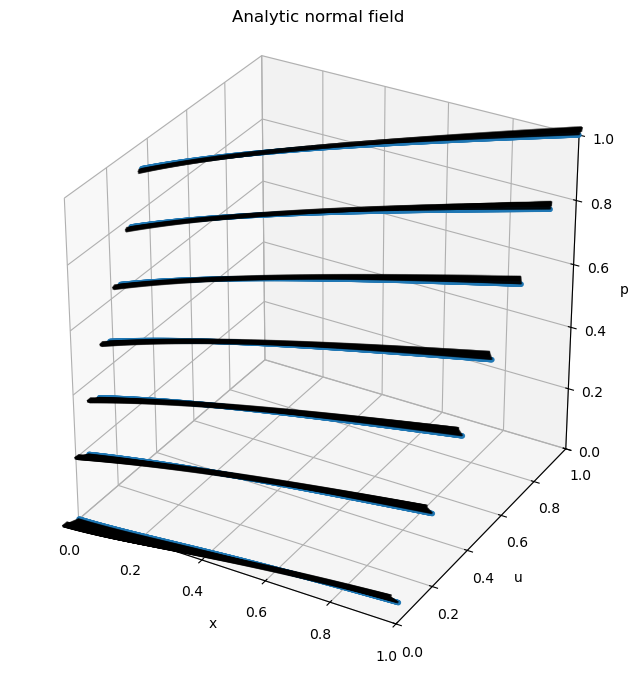

In [49]:
N = gtr.NORMALS[ode_args.ode](X_stacked[0], X_stacked[1])
# Try norlmalising N
# N = N / np.linalg.norm(N, axis=0)

fig_normal = plt.figure(figsize=(8,8))
ax_normal = fig_normal.add_subplot(projection='3d')

plot.scaled_3D_quiver(X_stacked, N, mode="normal", ax=ax_normal)
ax_normal.set_title("Analytic normal field")

## 3. Symmetry detection

(equivalent to `examples/run_odes_demo.py`)

Change `BASIS_TYPE`, `PARAM_RANGE`, or `PARAM_LIST` below and re-run from here
— the trajectories generated above are reused as-is. This first solves the
SVD; it does **not** decide which singular value(s) are "small" or which one
to reconstruct from — that's a separate, explicit choice made further down,
once you can see the results. The `characteristic` variable determines whether
we look for a characteristic or regular point symmetry.

Estimated null-space dimension: 1
Small singular value indices: [17]


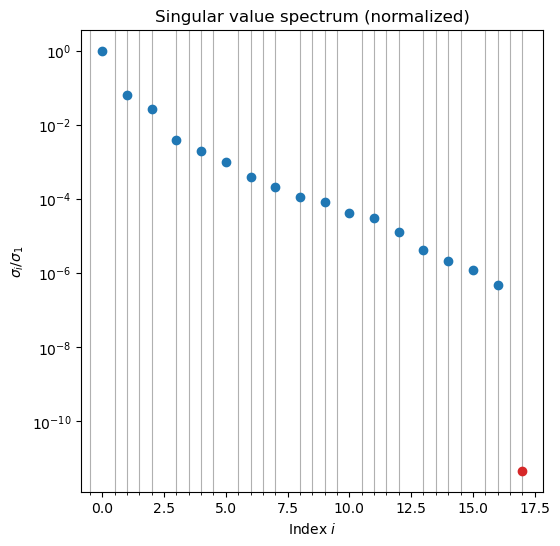

In [50]:
# --- Basis function family ---
# "monomial" or "chebyshev" (see symmetry_detection.basis_functions.BASIS_FUNCTIONS)
BASIS_TYPE = "monomial"
characteristic = False

# --- Basis elements: pick a range OR an explicit list, exactly like the CLI's
# --param_range / --param_list flags (see data_matrices.resolve_basis_args).
# PARAM_LIST always overrides PARAM_RANGE when it is not None.
PARAM_RANGE = (0, 2)  # all (m, n) pairs with m, n in 0..3
PARAM_LIST = None #[(0,0), (-2,2)] #[(0,0), (1,0), (-2,2)]    # e.g. [(0, 0), (1, 0), (0, 1), (2, 1)] to pick elements individually
sv_ratio = 1000

# Resolve basis parameters the same way the CLI does: PARAM_LIST overrides
# PARAM_RANGE, and any still-missing field falls back to symmetry_detection.defaults.
basis_args = argparse.Namespace(
    basis_type=BASIS_TYPE,
    param_range=list(PARAM_RANGE) if PARAM_RANGE is not None else None,
    param_list=PARAM_LIST,
)
basis_args = dm.resolve_basis_args(basis_args)

# Build the homogeneous system and solve its null space via SVD. This is
# pure linear algebra: solve_svd makes no judgment about which singular
# value(s) are "small" - that's a separate, explicit step below, done only
# after you can see svd_result.S here.
svd_result = solver.solve_svd(
    X_stacked, N,
    basis_type=basis_args.basis_type,
    param_range=basis_args.param_range,
    param_list=basis_args.param_list,
    characteristic=characteristic
)
small_sv_idx = solver.small_singular_value_indices(svd_result.S, drop_ratio=sv_ratio)
rpt.print_svd_summary(svd_result.S, small_sv_idx)

S_norm = svd_result.S / svd_result.S[0]
all_idx = np.arange(len(svd_result.S))
large_sv_idx = np.setdiff1d(all_idx, small_sv_idx, assume_unique=True)

fig3, ax3 = plt.subplots(figsize=(6, 6))

ax3.semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax3.semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax3.set_xlabel("Index $i$")
ax3.set_ylabel(r"$\sigma_i / \sigma_1$")
ax3.set_title("Singular value spectrum (normalized)")
ax3.set_box_aspect(1)
"""I need a fine grid"""
ax3.grid(which='minor')
ax3.minorticks_on()

### Base space infinitesimal generator

Based on the small singular value indices printed above, set `SV_CHOICE`
(0 = the largest of the small ones, up to `len(small_sv_idx) - 1` = the
globally smallest) and re-run from here. This only matters when the
estimated null space above has dimension > 1.

Selected singular value: sigma_17 = 2.869e-05 (out of 18)
Plotting point symmetry X = xi d/dx + eta d/du. Scaled by 0.5


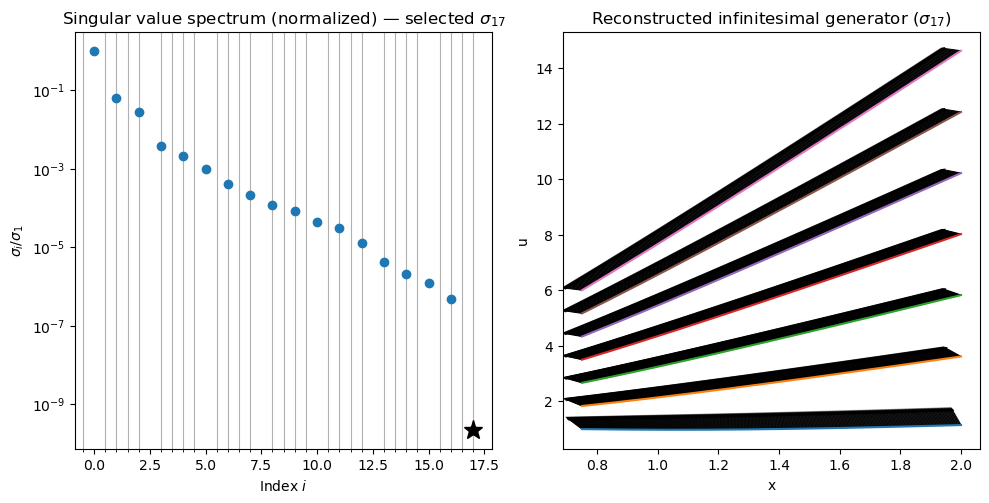

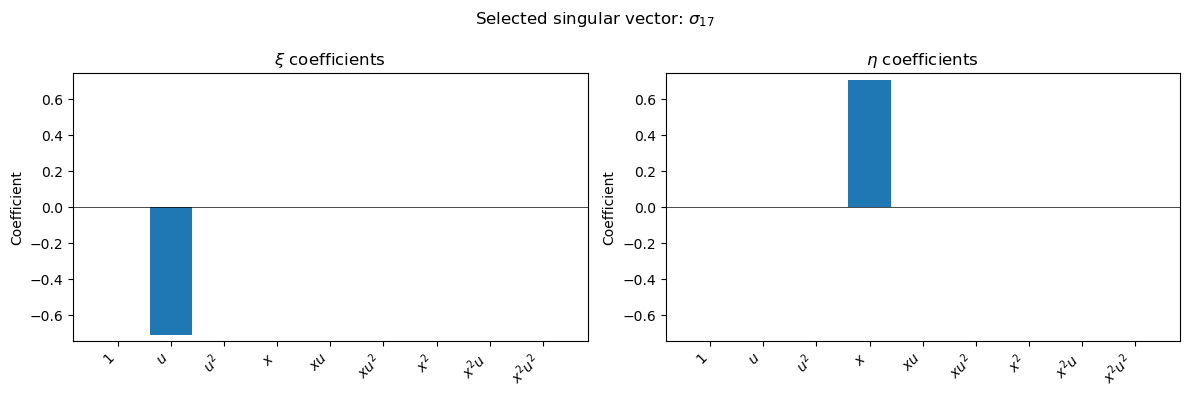

In [42]:
# Indexes into small_sv_idx, printed above (not an absolute S/Vt index).
# Out-of-range values are clamped to the nearest valid choice with a warning.
SV_CHOICE = 0
normalize_quiver = True
scale_quiver = 0.5

idx = solver.pick_small_singular_value(small_sv_idx, sv_choice=SV_CHOICE)
result = solver.select_singular_vector(svd_result, idx, characteristic=characteristic)
rpt.print_selection_summary(result.S, result.idx)

# Every plot below is derived from this one chosen singular vector.
sigma_label = rf"$\sigma_{{{result.idx}}}$"

# Same spectrum as above (fig3/ax3), on a new axis, with the chosen
# singular value starred.
fig4, ax4 = plt.subplots(1,2, figsize=(10, 6))

ax4[0].semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax4[0].semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax4[0].semilogy(result.idx, S_norm[result.idx], marker='*', markersize=14, linestyle='None', color='k', zorder=3)
ax4[0].set_xlabel("Index $i$")
ax4[0].set_ylabel(r"$\sigma_i / \sigma_1$")
ax4[0].set_title(f"Singular value spectrum (normalized) \u2014 selected {sigma_label}")
ax4[0].set_box_aspect(1)
ax4[0].grid(which='minor')
ax4[0].minorticks_on()

if normalize_quiver:
    xy_norm = np.sqrt(result.xi**2 + result.eta**2)
    xy_norm[xy_norm == 0] = 1
    ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi / xy_norm, result.eta / xy_norm, angles='uv', scale=20)
elif scale_quiver < 1:
    ax4[1].quiver(X_stacked[0], X_stacked[1], scale_quiver*result.xi, scale_quiver*result.eta, angles='uv', scale=20)
else:
    ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi, result.eta, angles='xy', scale=20, scale_units='xy')

for trajectory in X:
    ax4[1].plot(trajectory[0], trajectory[1])
ax4[1].set_xlabel("x")
ax4[1].set_ylabel("u")
ax4[1].set_title(f"Reconstructed infinitesimal generator ($\\sigma_{{{result.idx}}}$)")
ax4[1].set_box_aspect(1)

fig4.tight_layout()

# Coefficients
n_basis = len(result.param_list)

bars_fig, (ax_xi, ax_eta) = plt.subplots(1, 2, figsize=(12, 4))
bars_fig.suptitle(f"Selected singular vector: {sigma_label}")
coeff_ylim = plot.shared_coefficient_ylim(result.singular_vector[:n_basis], result.singular_vector[n_basis:])
plot.plot_basis_coefficient_bars(
    result.singular_vector[:n_basis], result.param_list, basis_args.basis_type,
    ax=ax_xi, title=r"$\xi$ coefficients", sort_by_magnitude=False, log_scale=False, ylim=coeff_ylim
)
plot.plot_basis_coefficient_bars(
    result.singular_vector[n_basis:], result.param_list, basis_args.basis_type,
    ax=ax_eta, title=r"$\eta$ coefficients", sort_by_magnitude=False, log_scale=False, ylim=coeff_ylim
)
bars_fig.tight_layout()

if characteristic:
    print(f"Plotting characteristic point symmetry Xhat = Q d/du, with Q = eta - u_x * xi. Scaled by {scale_quiver}")
else:
    print(f"Plotting point symmetry X = xi d/dx + eta d/du. Scaled by {scale_quiver}")

### Jet-space infinitesimal generator

In [ ]:
V = np.stack((result.xi, result.eta, result.zeta))

jet_fig, jet_ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(8, 8))
jet_fig.suptitle(f"Selected singular vector: {sigma_label}")
plot.scaled_3D_quiver(X_stacked, V, mode="tangent", ax=jet_ax)
jet_ax.set_title("Reconstructed infinitesimal generator (jet space)")
jet_ax.view_init(elev=0, azim=270, roll=0)
